In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgp_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgp_df_SR = pickle.load(open('sgp_set_resnet','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(40000, 3)
1s prop =  0.09895


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990
3,0.0,0.0,0.999980
4,0.0,0.0,0.999816


In [3]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)]
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):]

In [4]:
delta = 0.005
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds

In [5]:
color_map = {'standard': "#d51414",
             'FP': "#8F7A1C",
             'FN': "#0f770a",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#93139c",
             'SP': "#0F8592",
             'PPV': "#676767"}

### Joint evolution of metrics with respect to $\theta$

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 13.46it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 90.97it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:00<00:00, 89.72it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 15.52it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 91.01it/s] 


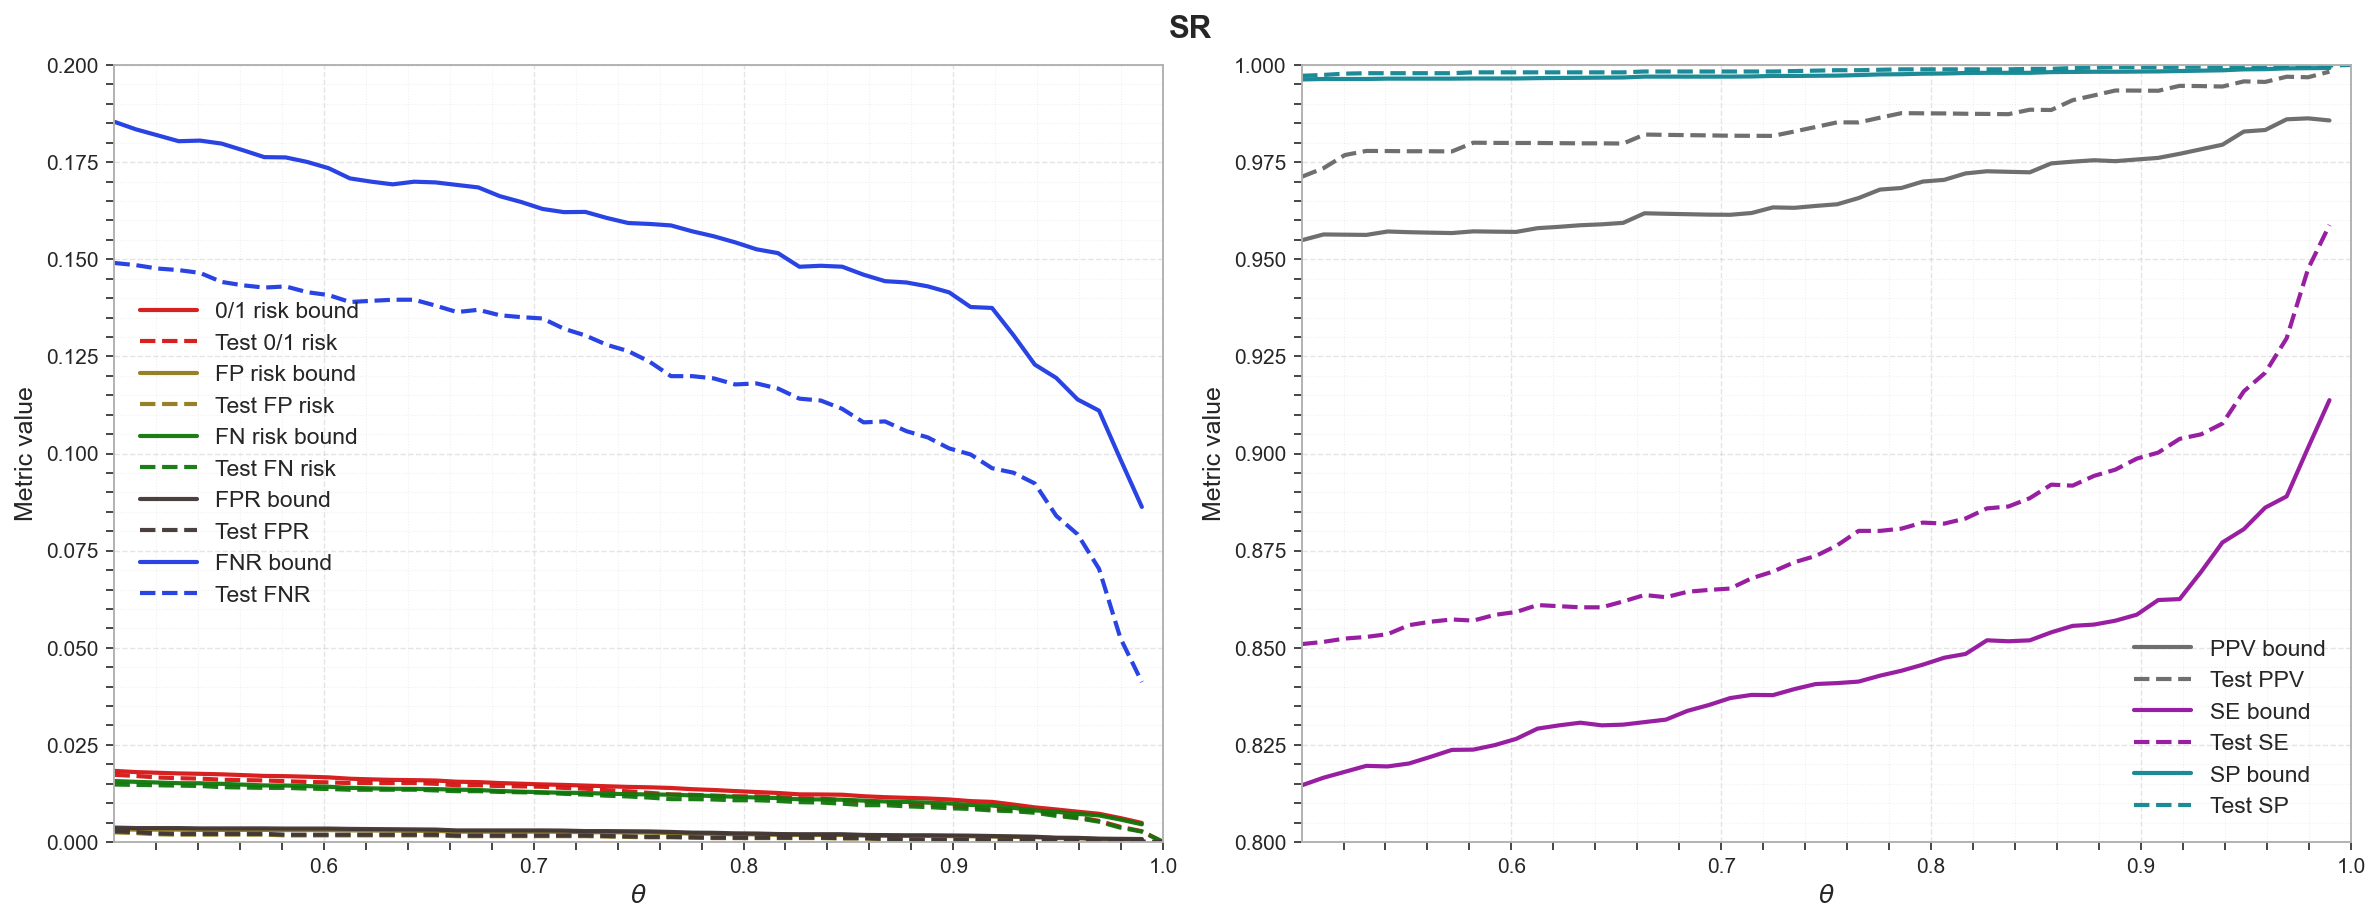

In [6]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 ylim1=[0,0.2], ylim2=[0.8,1])

standard  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 12.90it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 87.67it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:00<00:00, 89.61it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:03<00:00, 16.08it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:00<00:00, 84.44it/s]


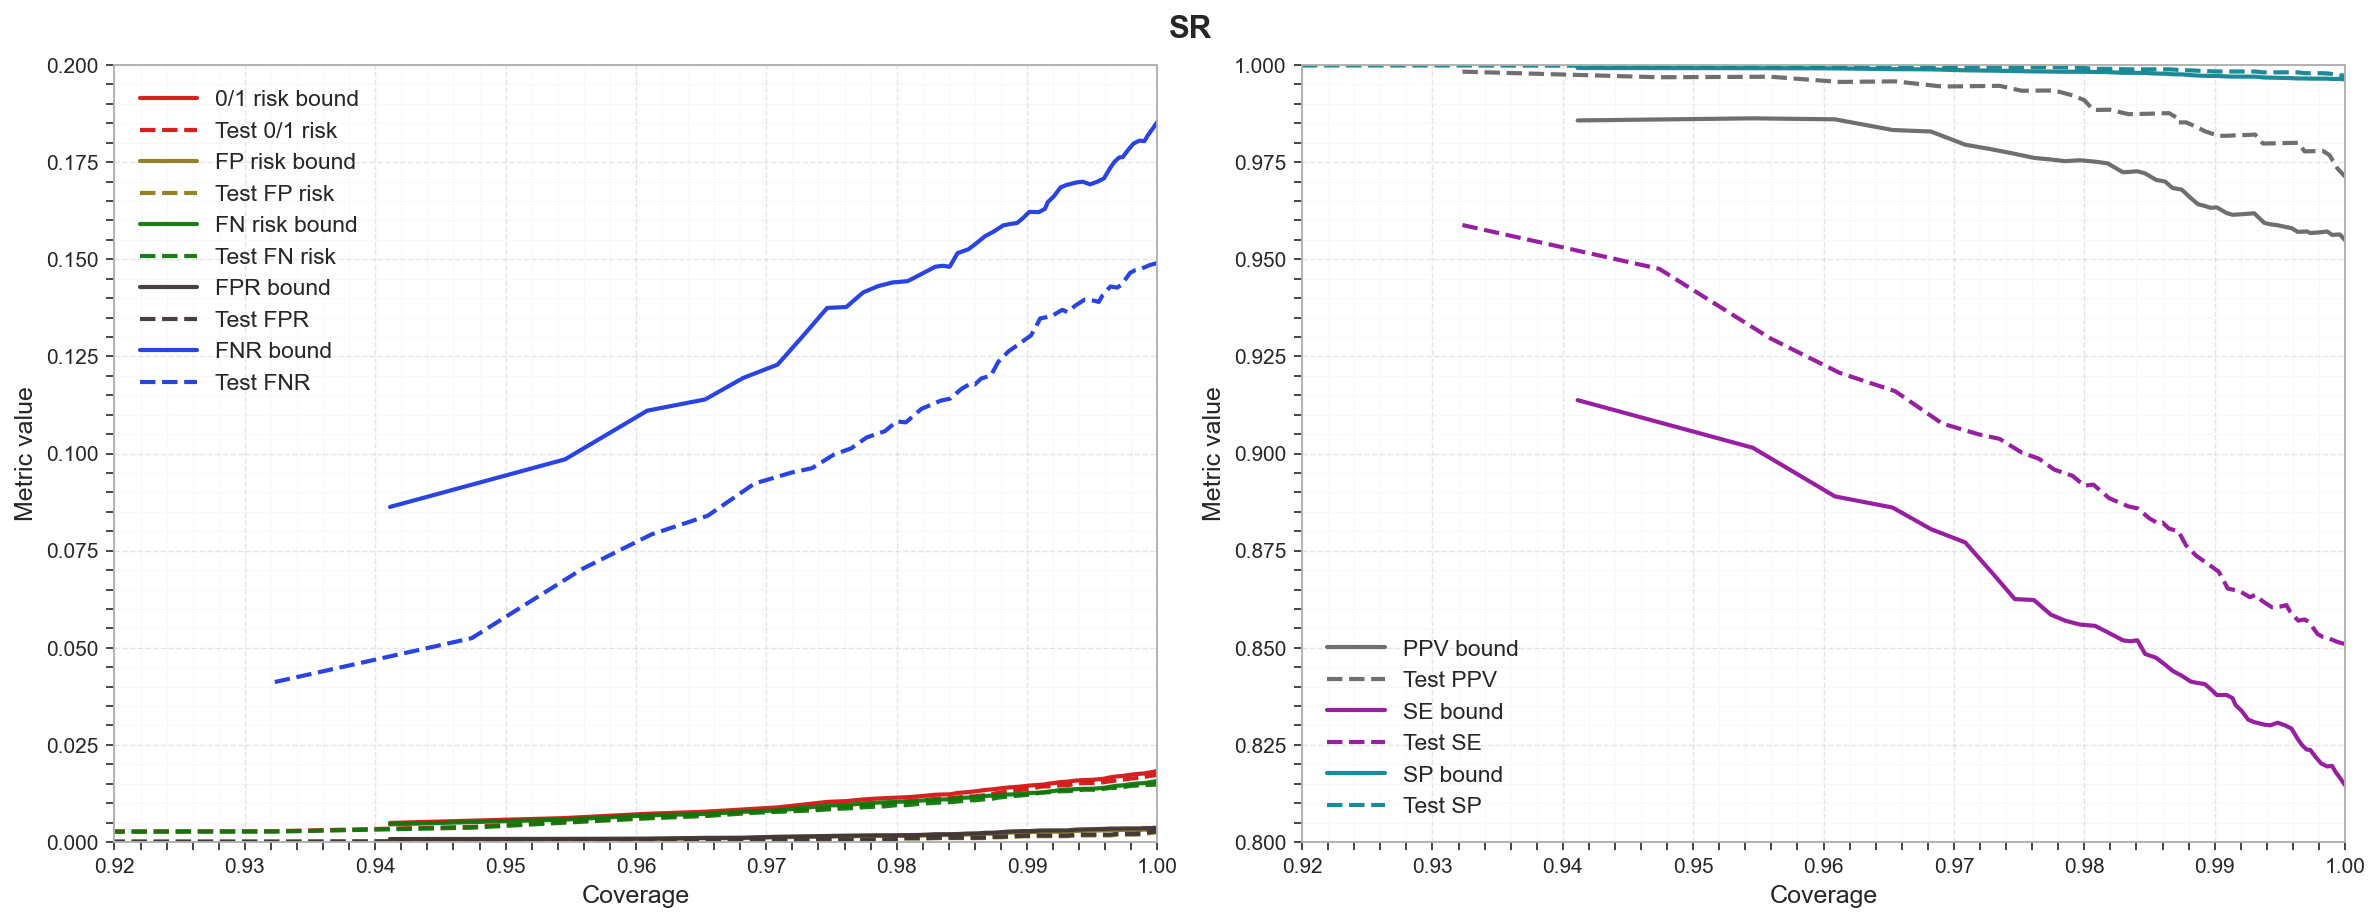

In [7]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 ylim1=[0,0.2], ylim2=[0.8,1],
                 xlim1=[0.92,1],xlim2=[0.92,1],
                 by_coverage=True)

### Find best $\theta$ in the intersection of metrics $\theta$ regions, if non empty

In [8]:
metrics_and_targets = {'FNR' : 0.2,
                       'FPR' : 0.1}

In [9]:
joint_output = joint_control(metrics_and_targets, train_set_SR, delta, plot=False)
joint_output

FNR  bounds


 99%|█████████▉| 99/100 [00:06<00:00, 15.85it/s]


FPR  bounds


 99%|█████████▉| 99/100 [00:01<00:00, 90.82it/s] 


{'theta_intervals': [(np.float64(0.5002623200416565),
   np.float64(0.9949521446468854))],
 'best_theta': np.float64(0.5002623200416565)}

### All reachable bounds for a couple of 2 metrics

In [10]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds_SR = reachable_bounds(metrics, train_set_SR, delta, steps=100)

standard  bounds


 99%|█████████▉| 99/100 [00:07<00:00, 13.68it/s]


FP  bounds


 99%|█████████▉| 99/100 [00:01<00:00, 86.40it/s] 


FN  bounds


...

 99%|█████████▉| 99/100 [00:01<00:00, 89.75it/s] 


SE  bounds


 99%|█████████▉| 99/100 [00:06<00:00, 15.82it/s]


SP  bounds


 99%|█████████▉| 99/100 [00:01<00:00, 89.42it/s] 


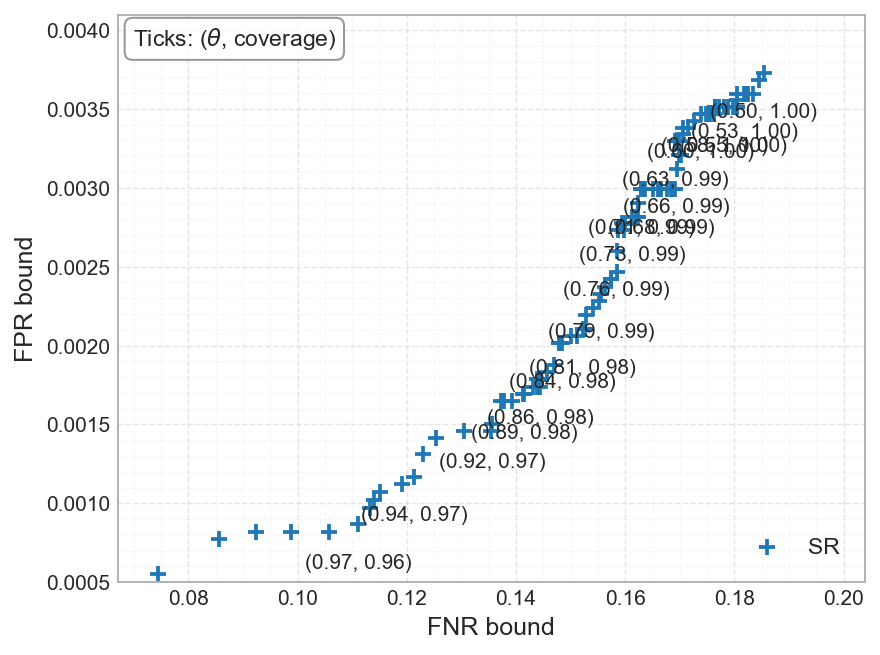

In [11]:
metric1 = 'FNR'
metric2 = 'FPR'

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD=None, num_labels=20)